# SupplyPrescript

# Sprint 2 - Data Understanding

## Objective

The objective of this notebook is to understand the logistics dataset before performing preprocessing and machine learning.

---

## Business Problem

Supply chain disruptions lead to delivery delays, increased transportation costs, and reduced customer satisfaction.

Our goal is to build an AI-powered system that:

- Predicts supply chain disruptions.
- Recommends the best business decision.
- Learns from previous decisions.

---

## Dataset

Logistics Supply Chain Dataset

Target Variable:

Disruption_Occurred

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

# 1. Load Dataset

In this section, we load the logistics dataset into a Pandas DataFrame to begin our analysis.

In [2]:
import os

print(os.getcwd())

c:\supplyprescript\SupplyPrescript\notebooks


In [7]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nFiles in data/raw:")

raw_path = "../data/raw"
print(os.listdir(raw_path))

Current Folder:
c:\supplyprescript\SupplyPrescript\notebooks

Files in data/raw:
['Added logistics dataset .csv.csv', 'README.md']


In [10]:
import pandas as pd

df = pd.read_csv("../data/raw/logistics_dataset.csv")



In [9]:
# Display first 5 rows
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [11]:
# Display last 5 rows
df.tail()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
4995,SC-14995,2025-11-10,Rotterdam,Dubai,Rail,Perishables,13512.26,428.97,3.35,8.8,Fog,0.664,20.28,0
4996,SC-14996,2025-11-23,Dubai,Shanghai,Air,Perishables,2231.02,448.86,1.79,0.5,Clear,0.863,0.50,0
4997,SC-14997,2025-10-18,Antwerp,Busan,Rail,Pharmaceuticals,5253.72,473.41,1.37,3.0,Clear,0.962,4.41,0
4998,SC-14998,2025-01-29,Singapore,Dubai,Rail,Automotive,12328.31,199.35,3.45,4.4,Storm,0.819,31.18,1
4999,SC-14999,2024-06-01,Dubai,Shanghai,Air,Textiles,9161.03,109.35,2.03,1.7,Storm,0.976,1.43,1


In [12]:
# Number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (5000, 14)


In [13]:
# Display all column names
df.columns

Index(['Shipment_ID', 'Date', 'Origin_Port', 'Destination_Port',
       'Transport_Mode', 'Product_Category', 'Distance_km', 'Weight_MT',
       'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Weather_Condition',
       'Carrier_Reliability_Score', 'Lead_Time_Days', 'Disruption_Occurred'],
      dtype='str')

In [14]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   str    
 1   Date                       5000 non-null   str    
 2   Origin_Port                5000 non-null   str    
 3   Destination_Port           5000 non-null   str    
 4   Transport_Mode             5000 non-null   str    
 5   Product_Category           5000 non-null   str    
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   str    
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   float64
 13  Disruption_Occurred        5000 non-null   int64  
dtypes: 

In [15]:
# Statistical summary of numerical columns
df.describe()

,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,7704.063888,246.252052,2.854552,5.076900,0.754387,19.355386,0.612600
std,4199.687885,142.522591,0.959533,2.877832,0.144363,31.405143,0.487205
min,500.170000,1.030000,1.200000,0.000000,0.500000,0.500000,0.000000
25%,4036.010000,124.330000,2.020000,2.600000,0.629000,2.110000,0.000000
50%,7750.125000,243.500000,2.840000,5.100000,0.757000,8.245000,1.000000
75%,11347.462500,366.955000,3.710000,7.500000,0.879000,21.207500,1.000000
max,14995.910000,499.750000,4.500000,10.000000,1.000000,236.390000,1.000000


In [16]:
# Missing values in each column
df.isnull().sum()

Shipment_ID                  0
Date                         0
Origin_Port                  0
Destination_Port             0
Transport_Mode               0
Product_Category             0
Distance_km                  0
Weight_MT                    0
Fuel_Price_Index             0
Geopolitical_Risk_Score      0
Weather_Condition            0
Carrier_Reliability_Score    0
Lead_Time_Days               0
Disruption_Occurred          0
dtype: int64

In [17]:
# Number of duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## Initial Observations

- Dataset loaded successfully.
- The dataset contains shipment records.
- Target variable: **Disruption_Occurred**.
- Numerical and categorical features are present.
- Data quality assessment will be performed before preprocessing.

In [19]:
# Target variable distribution
df["Disruption_Occurred"].value_counts()

Disruption_Occurred
1    3063
0    1937
Name: count, dtype: int64

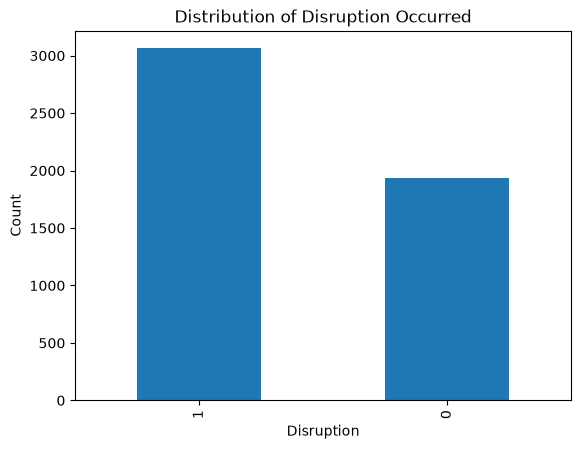

In [20]:
import matplotlib.pyplot as plt

df["Disruption_Occurred"].value_counts().plot(
    kind="bar",
    title="Distribution of Disruption Occurred"
)

plt.xlabel("Disruption")
plt.ylabel("Count")
plt.show()

## Initial Observations

- Dataset loaded successfully.
- Data contains shipment and logistics information.
- Target variable is **Disruption_Occurred**.
- Data quality assessment completed.
- Further preprocessing will be performed before model training.

# Business Insights

## Dataset Summary

- Total records: **5000**
- Total features: **14**
- Target variable: **Disruption_Occurred**

## Data Quality

- No missing values were found.
- No duplicate records were found.
- Dataset is clean and suitable for preprocessing.

## Target Variable Analysis

- Approximately **61.3%** of shipments experienced disruptions.
- Approximately **38.7%** of shipments were delivered without disruptions.
- The dataset is slightly imbalanced but still suitable for classification models.

## Initial Business Understanding

Potential factors affecting disruptions include:

- Transport Mode
- Weather Condition
- Geopolitical Risk
- Carrier Reliability
- Lead Time
- Distance
- Fuel Price Index